<a href="https://colab.research.google.com/github/AngelGarcia0905/IA/blob/main/AF_6_Aprendizaje_supervisado%2C_%C3%A1rbol_de_decisi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# 1. IMPORTACIÓN DE LIBRERÍAS Y DIAGNÓSTICO
# -----------------------------------------
# Esta celda centraliza todas las dependencias y verifica el hardware inicial.

import platform # Para obtener datos del sistema operativo.
import psutil   # Para estadísticas de hardware (CPU/RAM).
import os       # Para interactuar con variables de entorno de Colab.
import sys      # Para información del intérprete de Python.
import pandas   # Para manipulación de datos en tablas.
import sklearn  # Base de machine learning.
import matplotlib.pyplot as plt # Para creación de gráficos.
from sklearn.datasets import load_breast_cancer # Dataset oficial.
from sklearn.model_selection import train_test_split # Divisor de datos.
from sklearn.tree import DecisionTreeClassifier, plot_tree # Algoritmo y dibujo.
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report # Métricas.

def get_system_info():
    print(f"{'='*20} DIAGNÓSTICO DE HARDWARE {'='*20}")
    print(f"Sistema: {platform.system()} | Arquitectura: {platform.machine()}") # Info SO.
    print(f"Núcleos CPU: {psutil.cpu_count(logical=True)}") # Hilos totales.
    print(f"RAM Total: {round(psutil.virtual_memory().total / (1024**3), 2)} GB") # RAM en GB.
    entorno = "Google Colab" if 'COLAB_GPU' in os.environ else "Local" # Detecta entorno.
    print(f"Entorno detectado: {entorno}")

get_system_info() # Ejecuta el diagnóstico inicial.

==================== DIAGNÓSTICO DE HARDWARE ====================
Sistema: Linux | Arquitectura: x86_64
Núcleos CPU: 2
RAM Total: 12.67 GB
Entorno detectado: Google Colab


In [10]:
# 2. ENTORNO DE EJECUCIÓN Y VERSIONES
# -----------------------------------
# Esta celda confirma las versiones técnicas de las herramientas cargadas.

print(f"{'='*20} REPORTE DE VERSIONES {'='*20}")
print(f"Python: {sys.version}") # Versión del lenguaje.
print(f"Scikit-Learn: {sklearn.__version__}") # Versión de la librería de modelos.
print(f"Pandas: {pandas.__version__}") # Versión de manejo de datos.

print(f"\n{'='*10} MUESTRA DE LIBRERÍAS (PIP) {'='*10}")
!pip list | head -n 10 # Lista los primeros 10 paquetes instalados en el sistema.

==================== REPORTE DE VERSIONES ====================
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Scikit-Learn: 1.6.1
Pandas: 2.2.2

========== MUESTRA DE LIBRERÍAS (PIP) ==========
Package                                  Version
---------------------------------------- ------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.5
aiosignal                                1.4.0
ERROR: Pipe to stdout was broken
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


In [11]:
# 3. CARGA DE DATOS (BREAST CANCER)
# ---------------------------------
# Se extraen las características físicas y las etiquetas de diagnóstico.

datos = load_breast_cancer() # Carga el objeto completo del dataset.
X = datos.data # Matriz de características (medidas del tumor).
y = datos.target # Vector de etiquetas (0: Maligno, 1: Benigno).

print(f"Dataset: Breast Cancer Wisconsin (Diagnostic)") # Nombre del estudio.
print(f"Pacientes registrados: {X.shape[0]}") # Número de filas.
print(f"Variables medidas: {X.shape[1]}") # Número de columnas.
print(f"Clases a predecir: {datos.target_names}") # Nombres de los resultados.

Dataset: Breast Cancer Wisconsin (Diagnostic)
Pacientes registrados: 569
Variables medidas: 30
Clases a predecir: ['malignant' 'benign']


In [12]:
# 4. PREPROCESAMIENTO (DIVISIÓN 80/20)
# ------------------------------------
# Se separa la información para entrenamiento y para validación posterior.

# Divide los datos dejando el 20% para la prueba final (test_size=0.20).
# random_state=42 fija la aleatoriedad para que el resultado no cambie.
train_data, test_data, train_labels, test_labels = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Datos para Entrenamiento: {len(train_data)} registros.") # El 80%.
print(f"Datos para Prueba: {len(test_data)} registros.") # El 20%.

Datos para Entrenamiento: 455 registros.
Datos para Prueba: 114 registros.


In [13]:
# 5. SELECCIÓN Y ENTRENAMIENTO DEL MODELO
# ---------------------------------------
# Se entrena el Árbol de Decisión con los datos de entrenamiento.

modelo = DecisionTreeClassifier(random_state=42) # Crea el objeto del modelo.

modelo.fit(train_data, train_labels) # Entrena el árbol con los datos (fit).

predicciones = modelo.predict(test_data) # Realiza predicciones sobre los datos de prueba.

print("Aprendizaje completado. El modelo está listo para evaluación.")

Aprendizaje completado. El modelo está listo para evaluación.


MATRIZ DE CONFUSIÓN:
[[40  3]
 [ 3 68]]

Exactitud (Accuracy): 94.74%

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



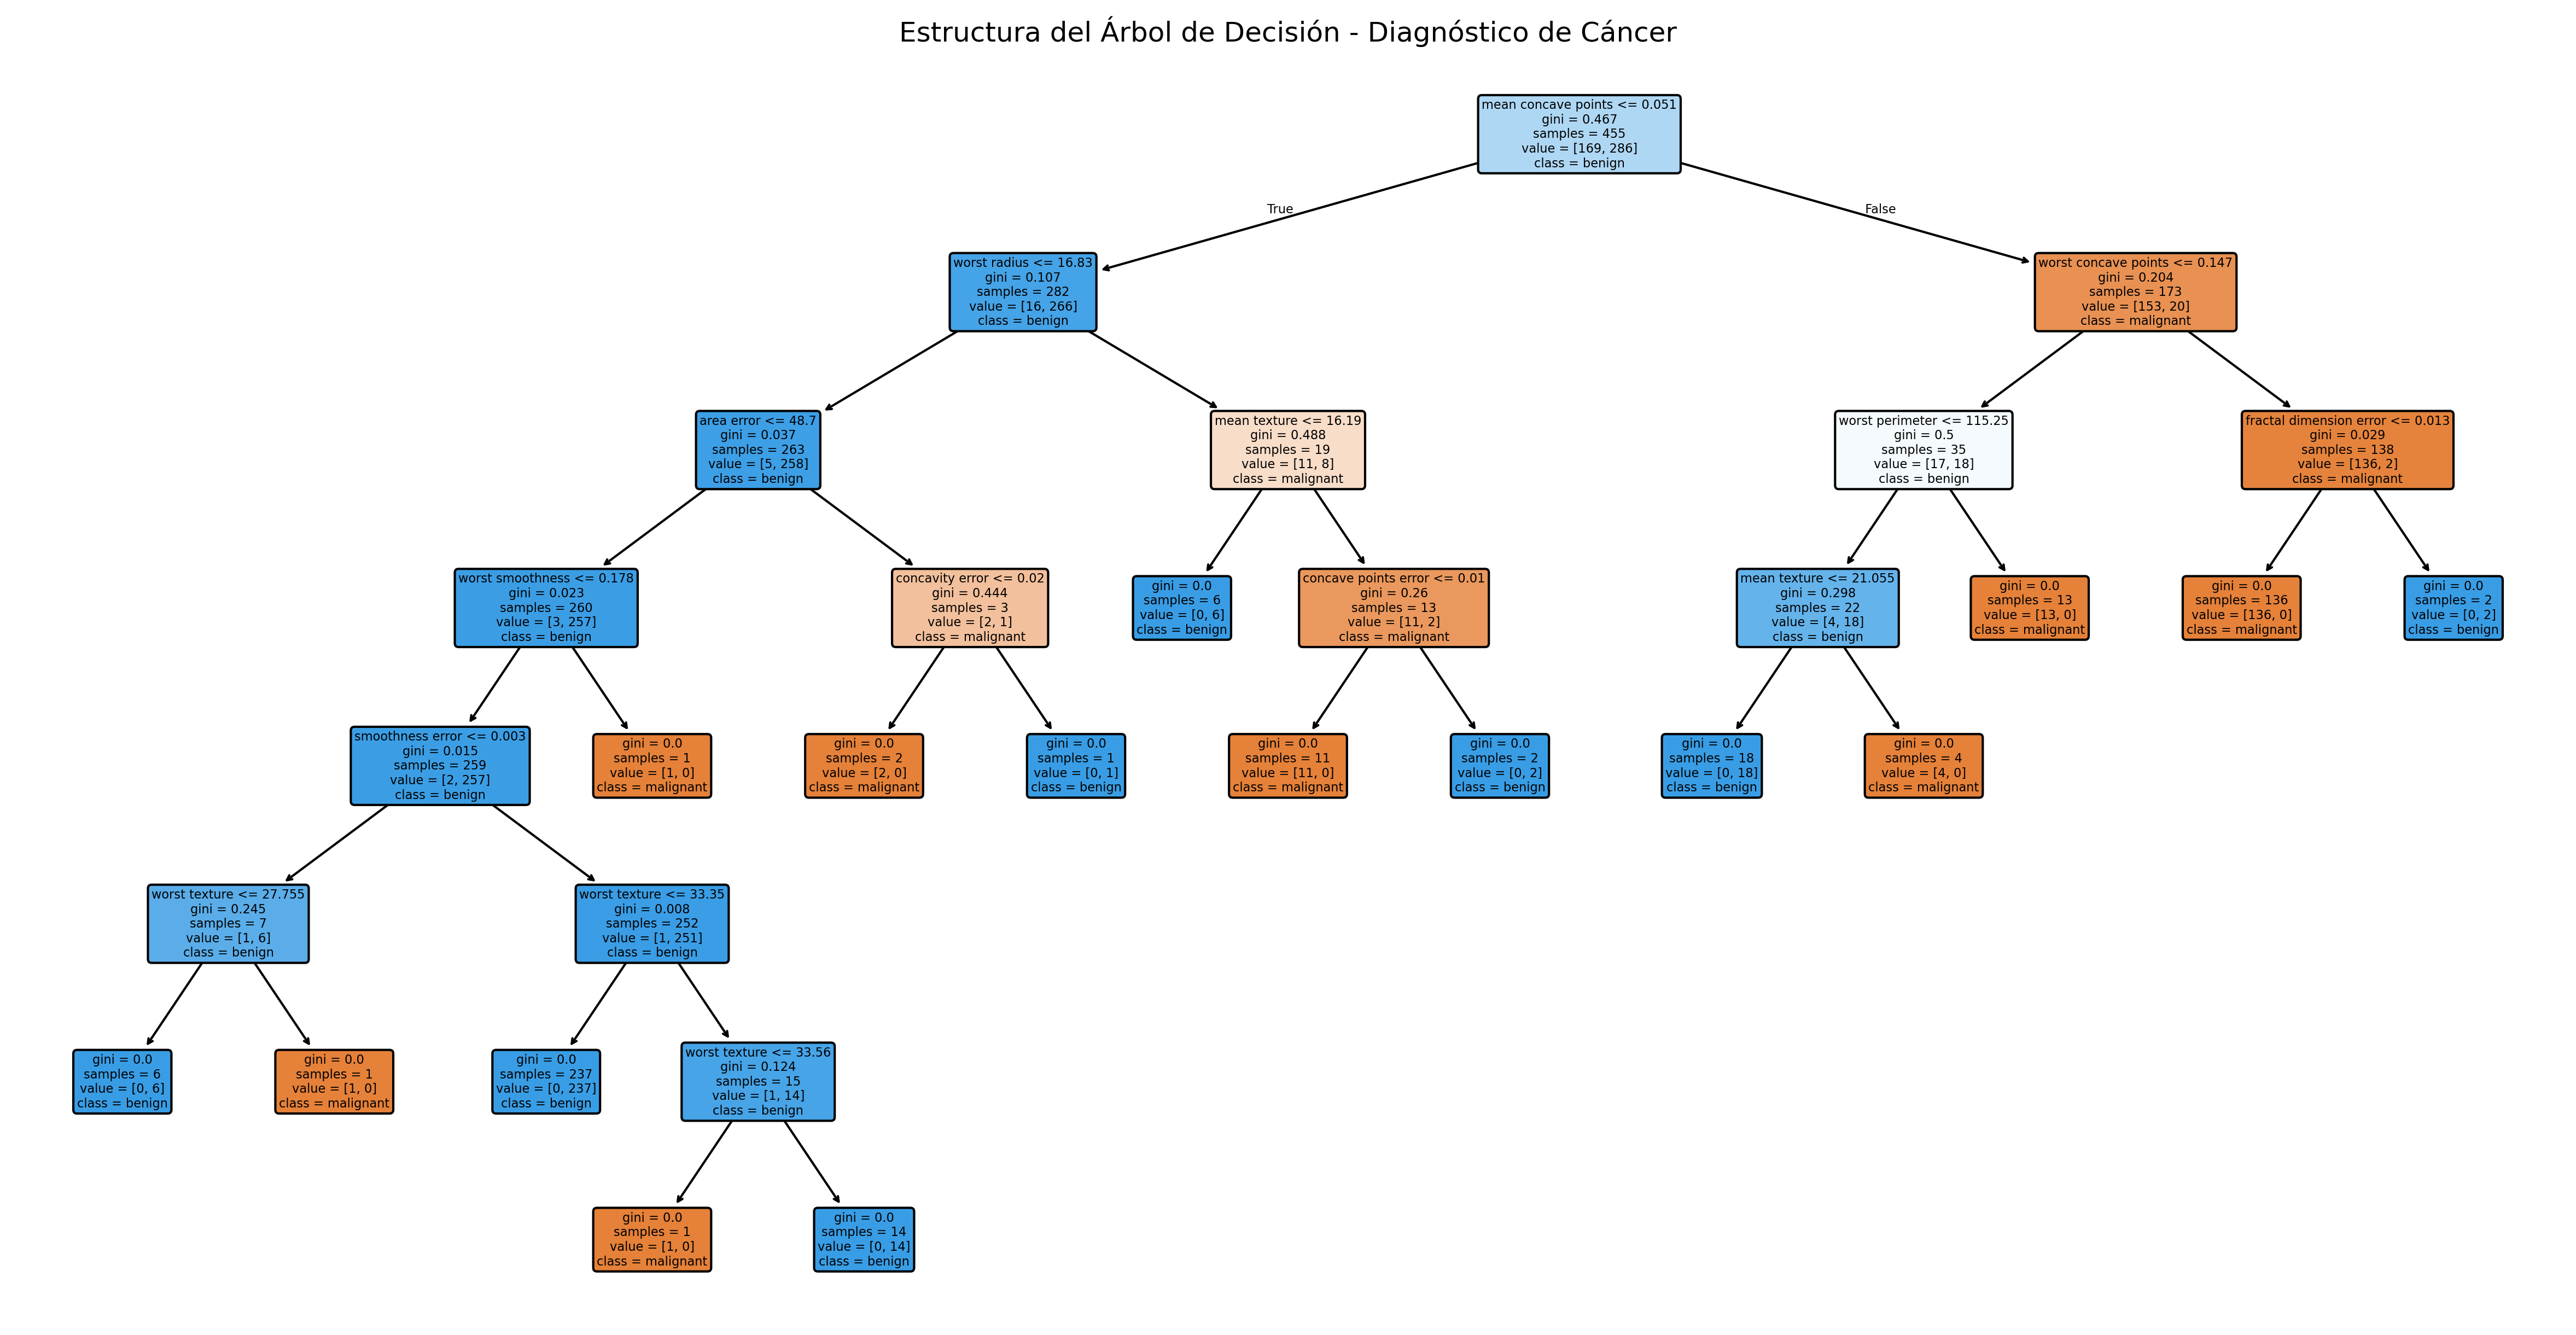

In [15]:
# 6. EVALUACIÓN Y VISUALIZACIÓN (300 DPI)
# ---------------------------------------
# Genera métricas de precisión y el diagrama del árbol en alta resolución.

print("MATRIZ DE CONFUSIÓN:")
print(confusion_matrix(test_labels, predicciones)) # Muestra aciertos y errores.

acc = accuracy_score(test_labels, predicciones) # Calcula la precisión.
print(f"\nExactitud (Accuracy): {acc * 100:.2f}%") # Muestra el porcentaje.

print("\nREPORTE DE CLASIFICACIÓN:")
print(classification_report(test_labels, predicciones, target_names=datos.target_names))

plt.figure(figsize=(20,10), dpi=300) # Configura el gráfico a 300 DPI.
plot_tree(modelo,
          feature_names=datos.feature_names, # Nombres de las medidas médicas.
          class_names=datos.target_names, # Nombres de los diagnósticos.
          filled=True, # Colorea según la clase predominante.
          rounded=True) # Bordes redondeados para mejor diseño.

plt.title("Estructura del Árbol de Decisión - Diagnóstico de Cáncer") # Título.
plt.show() # Muestra la imagen.

In [14]:
# 7. GLOSARIO EXPLICATIVO (CÓDIGO)
# --------------------------------
# Imprime una guía sencilla para interpretar los términos del árbol.

def mostrar_ayuda():
    guia = {
        "Gini": "Mide qué tan mezclados están los datos (0.0 es pureza total).",
        "Samples": "Número de pacientes analizados en ese cuadro.",
        "Value [M, B]": "Cantidad de pacientes [Malignos, Benignos] en ese nodo.",
        "Class": "Conclusión o diagnóstico que sugiere el árbol en ese punto.",
        "True / False": "Caminos según si se cumple o no la condición de arriba.",
        "Azul / Naranja": "Azul indica tendencia Benigna, Naranja tendencia Maligna."
    }

    print(f"{'='*20} GUÍA DE LECTURA {'='*20}\n")
    for k, v in guia.items():
        print(f"• {k.ljust(15)} : {v}") # Imprime cada término alineado.

mostrar_ayuda() # Ejecuta la impresión de la guía.

==================== GUÍA DE LECTURA ====================

• Gini            : Mide qué tan mezclados están los datos (0.0 es pureza total).
• Samples         : Número de pacientes analizados en ese cuadro.
• Value [M, B]    : Cantidad de pacientes [Malignos, Benignos] en ese nodo.
• Class           : Conclusión o diagnóstico que sugiere el árbol en ese punto.
• True / False    : Caminos según si se cumple o no la condición de arriba.
• Azul / Naranja  : Azul indica tendencia Benigna, Naranja tendencia Maligna.
